# SENA: Search Engine with Neural Attention for Long COVID Retrieval

## Author: Sina Bonakdar, University of Michigan, Ann Arbor, MI

## Project Final of STATS 507 Course with Dr. Xian Zhang

### This notebook included the codes for the final project

# 1- Load the dataset from Hugging Face

In [1]:
from datasets import load_dataset
import warnings
# Suppress all warnings globally
warnings.filterwarnings("ignore")
dataset = load_dataset("llangnickel/long-covid-classification-data")

/Users/bonakdar/stats507-coursework/Final-Project/.env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(dataset)
print(len(dataset['train']) + len(dataset['test']))

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'text', 'label'],
        num_rows: 414
    })
    test: Dataset({
        features: ['Unnamed: 0', 'text', 'label'],
        num_rows: 138
    })
})
552


This dataset contains 414 train and 138 test data, in total we have 552 data

# 2- Visualization of data

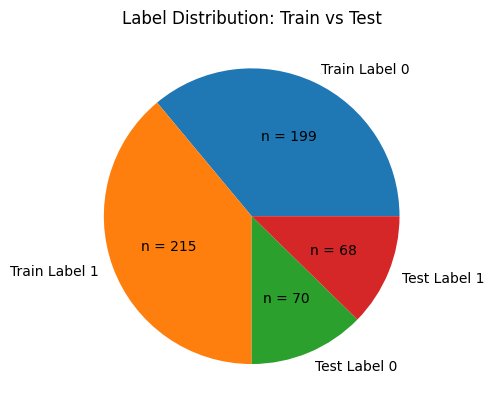

In [3]:
import matplotlib.pyplot as plt

# Extract labels
train_labels = dataset["train"]["label"]
test_labels = dataset["test"]["label"]

# Count each group
train_0 = sum(1 for x in train_labels if x == 0)
train_1 = sum(1 for x in train_labels if x == 1)
test_0 = sum(1 for x in test_labels if x == 0)
test_1 = sum(1 for x in test_labels if x == 1)

sizes = [train_0, train_1, test_0, test_1]

labels = [
    "Train Label 0",
    "Train Label 1",
    "Test Label 0",
    "Test Label 1"
]

# Custom function to show counts instead of %
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"n = {count}"
    return my_autopct

plt.figure()
plt.pie(sizes, labels=labels, autopct=make_autopct(sizes))
plt.title("Label Distribution: Train vs Test")
plt.show()

Label 0 states as COVID papers which are not related to Long COVID, and papers with label 1 are the papers related to Long COVID paper. 

# 3- Check the missing values

In [4]:
import math

def check_missing(split_name, labels):
    missing = sum(
        1 for x in labels
        if x is None or (isinstance(x, float) and math.isnan(x))
    )
    print(f"{split_name}: {missing} missing values out of {len(labels)}")

check_missing("Train", dataset["train"]["label"])
check_missing("Test", dataset["test"]["label"])

Train: 0 missing values out of 414
Test: 0 missing values out of 138


There is no missing value in either train or test splits. 

# 4- How input and output data looks like

In [5]:
#how texts (inputs) look like
dataset['train']['text'][0]

'Harnessing the immune system to overcome cytokine storm and reduce viral load in COVID 19 a review of the phases of illness and therapeutic agents Coronavirus disease 2019 COVID 19 is caused by Severe Acute Respiratory Syndrome Coronavirus 2 SARS CoV 2 previously named 2019 nCov a novel coronavirus that emerged in China in December 2019 and was declared a global pandemic by World Health Organization by March 11th 2020 Severe manifestations of COVID 19 are caused by a combination of direct tissue injury by viral replication and associated cytokine storm resulting in progressive organ damage We reviewed published literature between January 1st 2000 and June 30th 2020 excluding articles focusing on pediatric or obstetric population with a focus on virus host interactions and immunological mechanisms responsible for virus associated cytokine release syndrome CRS COVID 19 illness encompasses three main phases In phase 1 SARS CoV 2 binds with angiotensin converting enzyme ACE 2 receptor on 

The input data includes the title and abstract of paper. Input format is text and needs to be tokenized for further analyses. 

In [6]:
#how labels look like
dataset['train']['label']

Column([0, 0, 1, 1, 1, ...])

The output data is also binary including 0 and 1 values where 0 represents non Long COVID and 1 represents Long COVID papers.

# 5- Tokenization of data and set the format to be compatible with pytorch

In [7]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
#tokenization of all data (batches of examples)
def tokenization(example):
    return tokenizer(
        example["text"],
        padding="max_length",     # pad all to same length
        truncation=True,          # cut long sequences
        max_length=512            # BERT standard
    )

dataset = dataset.map(tokenization, batched=True)
dataset

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 414
    })
    test: Dataset({
        features: ['Unnamed: 0', 'text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 138
    })
})

In [8]:
#set format to be compatible with pytorch
dataset.set_format(type="torch", columns=["input_ids", "token_type_ids", "attention_mask", "label"])

dataset is now tokenized and ready to be used with poytorch

# 6- Multi-layer Perceptron (MLP) as baseline model

Epoch 1, Total Loss: 17.6771
Epoch 1:
Train Loss: 0.6799, Train Acc: 0.6329
Test  Loss: 0.6580, Test  Acc: 0.7174
----------------------------------------
Epoch 2, Total Loss: 16.2141
Epoch 2:
Train Loss: 0.6236, Train Acc: 0.7778
Test  Loss: 0.5815, Test  Acc: 0.7826
----------------------------------------
Epoch 3, Total Loss: 13.4631
Epoch 3:
Train Loss: 0.5178, Train Acc: 0.8285
Test  Loss: 0.4804, Test  Acc: 0.8116
----------------------------------------
Epoch 4, Total Loss: 10.3430
Epoch 4:
Train Loss: 0.3978, Train Acc: 0.8575
Test  Loss: 0.3957, Test  Acc: 0.8551
----------------------------------------
Epoch 5, Total Loss: 7.6207
Epoch 5:
Train Loss: 0.2931, Train Acc: 0.9034
Test  Loss: 0.3451, Test  Acc: 0.8406
----------------------------------------
Epoch 6, Total Loss: 5.7080
Epoch 6:
Train Loss: 0.2195, Train Acc: 0.9348
Test  Loss: 0.3202, Test  Acc: 0.8478
----------------------------------------
Epoch 7, Total Loss: 4.1637
Epoch 7:
Train Loss: 0.1601, Train Acc: 0.95

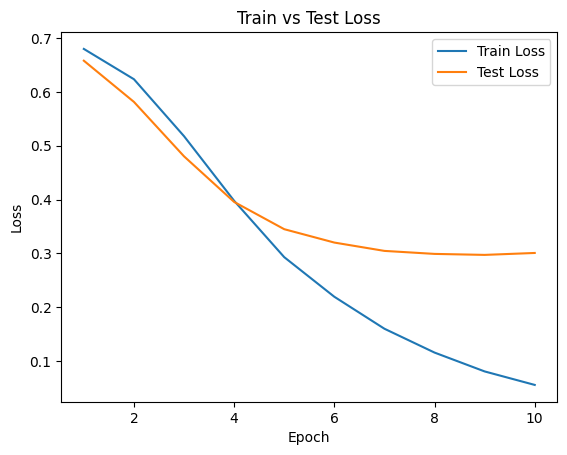

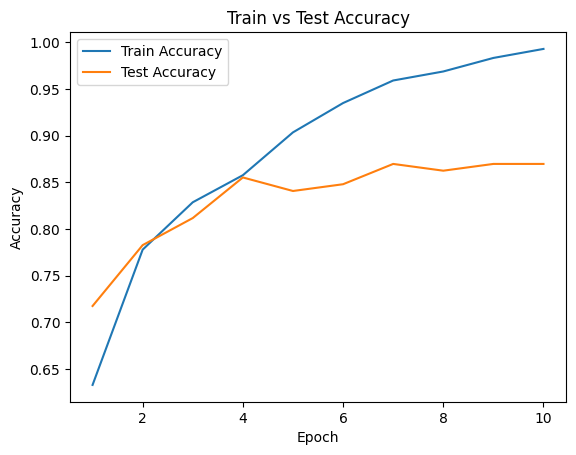

In [9]:
#MLP 
#padding on whole data to 512 length
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

train_loader = DataLoader(dataset["train"], batch_size=16, shuffle=True)
test_loader = DataLoader(dataset["test"], batch_size=16)

class MLP(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(MLP, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim) #convert token ID to dense vectors

        self.fc1 = nn.Linear(embed_dim, hidden_dim) #first layer
        self.relu = nn.ReLU() #non linear activation
        self.fc2 = nn.Linear(hidden_dim, 2) #output layer

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        mask = attention_mask.unsqueeze(-1)
        x = x * mask
        x = x.sum(dim=1) / mask.sum(dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
        
    
vocab_size = tokenizer.vocab_size
model = MLP(vocab_size, embed_dim=128, hidden_dim=64)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# store metrics
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

#training: 
epochs = range(1, 11)
for epoch in epochs:
    model.train()
    total_loss = 0
    all_train_preds, all_train_labels = [], []
    
    for batch in train_loader: #loop over batches
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["label"]
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    train_loss = total_loss / len(train_loader)
    train_acc = accuracy_score(all_train_labels, all_train_preds)
    print(f"Epoch {epoch}, Total Loss: {total_loss:.4f}")

    # ---- TEST ----
    model.eval()
    total_loss = 0
    all_test_preds, all_test_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"]
            attention_mask = batch["attention_mask"]
            labels = batch["label"]

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_test_preds.extend(preds.cpu().numpy())
            all_test_labels.extend(labels.cpu().numpy())
            
    test_loss = total_loss / len(test_loader)
    test_acc = accuracy_score(all_test_labels, all_test_preds)
    # store metrics
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f}, Test  Acc: {test_acc:.4f}")
    print("-" * 40)



model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["label"]

        outputs = model(input_ids, attention_mask)
        predictions = torch.argmax(outputs, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy_mlp = sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)
f1_mlp = f1_score(all_labels, all_preds)
precision_mlp = precision_score(all_labels, all_preds)
recall_mlp = recall_score(all_labels, all_preds)

print('\nFinal model performance on test set: ')
print("Accuracy:", accuracy_mlp)
print("F1-score:", f1_mlp)
print("Precision:", precision_mlp)
print("Recall:", recall_mlp)

# ---- PLOTS ----

# Loss plot
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()
plt.show()

# Accuracy plot
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.show()


The MLP model consists of an embedding layer that maps tokens into 128-dimensional vectors, followed by masked average pooling to obtain a fixed-length sentence representation. This representation is passed through a single hidden fully connected layer with 64 neurons and ReLU activation, and finally through an output layer with 2 neurons for binary classification. The model is trained using cross-entropy loss and the Adam optimizer.

Input text
   ↓
Token IDs (from tokenizer)
   ↓
Embedding layer
   ↓
Masking (remove padding influence)
   ↓
Average pooling (collapse sequence → single vector)
   ↓
Fully Connected Layer (fc1)
   ↓
ReLU activation
   ↓
Fully Connected Layer (fc2)
   ↓
Output logits (2 classes)

# 8- LSTM Models

Optimized LSTM: 

Epoch 1, Total Loss: 17.6885
Epoch 1:
Train Loss: 0.6803, Train Acc: 0.5483
Test  Loss: 0.6219, Test  Acc: 0.7536
----------------------------------------
Epoch 2, Total Loss: 14.3197
Epoch 2:
Train Loss: 0.5508, Train Acc: 0.7681
Test  Loss: 0.4073, Test  Acc: 0.8261
----------------------------------------
Epoch 3, Total Loss: 9.3024
Epoch 3:
Train Loss: 0.3578, Train Acc: 0.8430
Test  Loss: 0.4252, Test  Acc: 0.8188
----------------------------------------
Epoch 4, Total Loss: 4.9660
Epoch 4:
Train Loss: 0.1910, Train Acc: 0.9227
Test  Loss: 0.4075, Test  Acc: 0.8188
----------------------------------------
Epoch 5, Total Loss: 1.6650
Epoch 5:
Train Loss: 0.0640, Train Acc: 0.9879
Test  Loss: 0.4442, Test  Acc: 0.8406
----------------------------------------
Epoch 6, Total Loss: 0.9900
Epoch 6:
Train Loss: 0.0381, Train Acc: 0.9928
Test  Loss: 0.4450, Test  Acc: 0.8551
----------------------------------------
Epoch 7, Total Loss: 0.6419
Epoch 7:
Train Loss: 0.0247, Train Acc: 0.9952

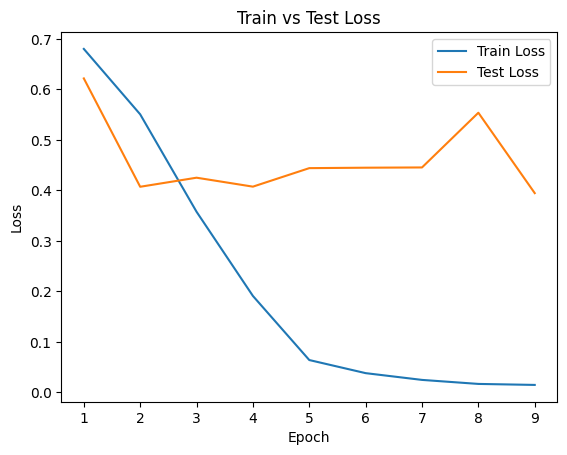

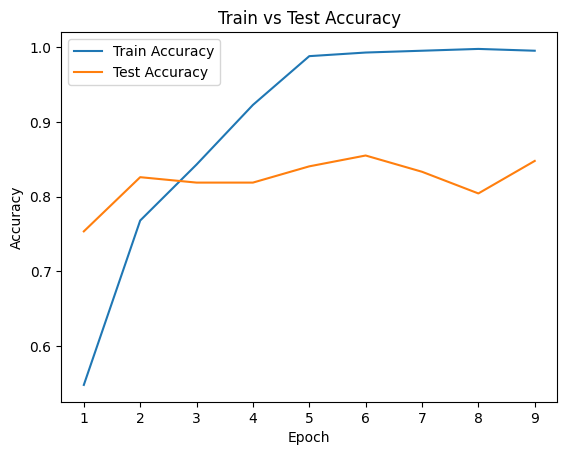

In [10]:
#optimized: bi-directional 
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            input_size=embed_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True, 
            bidirectional=True # keep simple (can upgrade later)
        )
        self.dropout = nn.Dropout(0.5)
        #self.fc = nn.Linear(hidden_dim, 2) for 1 directional 
        self.fc = nn.Linear(hidden_dim * 2, 2) #for bidirectional 

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids) # (batch, seq_len, embed_dim)
        
        # Pack padded sequences (important for efficiency)
        lengths = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths, batch_first=True, enforce_sorted=False 
        )
        packed_output, (hidden, cell) = self.lstm(packed)

        # Take last hidden state
        #out = hidden[-1] # (batch, hidden_dim) 1 directional 
        out = torch.cat((hidden[-2], hidden[-1]), dim=1) #bidirectional 
        out = self.dropout(out) 
        out = self.fc(out) 
        return out

vocab_size = tokenizer.vocab_size 
model = LSTMClassifier(vocab_size, embed_dim=128, hidden_dim=128) 
criterion = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        
# store metrics
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

#training: 
epochs = range(1, 10)
for epoch in epochs:
    model.train()
    total_loss = 0
    all_train_preds, all_train_labels = [], []
    
    for batch in train_loader: #loop over batches
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["label"]
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    train_loss = total_loss / len(train_loader)
    train_acc = accuracy_score(all_train_labels, all_train_preds)
    print(f"Epoch {epoch}, Total Loss: {total_loss:.4f}")

    # ---- TEST ----
    model.eval()
    total_loss = 0
    all_test_preds, all_test_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"]
            attention_mask = batch["attention_mask"]
            labels = batch["label"]

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_test_preds.extend(preds.cpu().numpy())
            all_test_labels.extend(labels.cpu().numpy())
            
    test_loss = total_loss / len(test_loader)
    test_acc = accuracy_score(all_test_labels, all_test_preds)
    # store metrics
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f}, Test  Acc: {test_acc:.4f}")
    print("-" * 40)



model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["label"]

        outputs = model(input_ids, attention_mask)
        predictions = torch.argmax(outputs, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy_ls = sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)
f1_ls = f1_score(all_labels, all_preds)
precision_ls = precision_score(all_labels, all_preds)
recall_ls = recall_score(all_labels, all_preds)

print('\nFinal model performance on test set: ')
print("Accuracy:", accuracy_ls)
print("F1-score:", f1_ls)
print("Precision:", precision_ls)
print("Recall:", recall_ls)

# ---- PLOTS ----

# Loss plot
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()
plt.show()

# Accuracy plot
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.show()


Epoch 1, Total Loss: 18.0312
Epoch 1:
Train Loss: 0.6935, Train Acc: 0.5217
Test  Loss: 0.6820, Test  Acc: 0.5507
----------------------------------------
Epoch 2, Total Loss: 17.1699
Epoch 2:
Train Loss: 0.6604, Train Acc: 0.6063
Test  Loss: 0.6553, Test  Acc: 0.6449
----------------------------------------
Epoch 3, Total Loss: 14.3370
Epoch 3:
Train Loss: 0.5514, Train Acc: 0.7488
Test  Loss: 0.6574, Test  Acc: 0.6159
----------------------------------------
Epoch 4, Total Loss: 11.0486
Epoch 4:
Train Loss: 0.4249, Train Acc: 0.8430
Test  Loss: 0.6632, Test  Acc: 0.6522
----------------------------------------
Epoch 5, Total Loss: 7.3930
Epoch 5:
Train Loss: 0.2843, Train Acc: 0.8961
Test  Loss: 0.8705, Test  Acc: 0.6159
----------------------------------------
Epoch 6, Total Loss: 5.1264
Epoch 6:
Train Loss: 0.1972, Train Acc: 0.9348
Test  Loss: 0.6973, Test  Acc: 0.6812
----------------------------------------
Epoch 7, Total Loss: 2.6235
Epoch 7:
Train Loss: 0.1009, Train Acc: 0.97

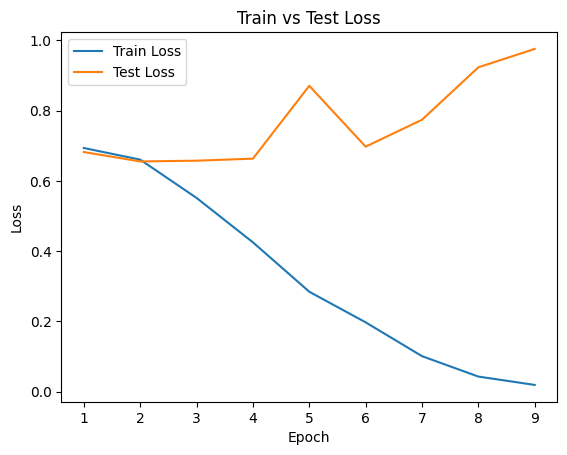

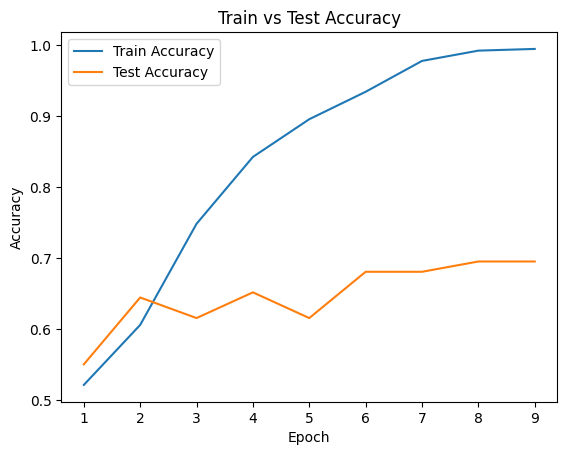

In [11]:
#uni directional - not efficient 
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            input_size=embed_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True, 
            bidirectional=False # keep simple (can upgrade later)
        )
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, 2) #for 1 directional 
        #self.fc = nn.Linear(hidden_dim * 2, 2) #for bidirectional 

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids) # (batch, seq_len, embed_dim)
        
        # Pack padded sequences (important for efficiency)
        lengths = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths, batch_first=True, enforce_sorted=False 
        )
        packed_output, (hidden, cell) = self.lstm(packed)

        # Take last hidden state
        out = hidden[-1] # (batch, hidden_dim) 1 directional 
        #out = torch.cat((hidden[-2], hidden[-1]), dim=1) #bidirectional 
        out = self.dropout(out) 
        out = self.fc(out) 
        return out

vocab_size = tokenizer.vocab_size 
model = LSTMClassifier(vocab_size, embed_dim=128, hidden_dim=128) 
criterion = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        
# store metrics
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

#training: 
epochs = range(1, 10)
for epoch in epochs:
    model.train()
    total_loss = 0
    all_train_preds, all_train_labels = [], []
    
    for batch in train_loader: #loop over batches
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["label"]
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    train_loss = total_loss / len(train_loader)
    train_acc = accuracy_score(all_train_labels, all_train_preds)
    print(f"Epoch {epoch}, Total Loss: {total_loss:.4f}")

    # ---- TEST ----
    model.eval()
    total_loss = 0
    all_test_preds, all_test_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"]
            attention_mask = batch["attention_mask"]
            labels = batch["label"]

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_test_preds.extend(preds.cpu().numpy())
            all_test_labels.extend(labels.cpu().numpy())
            
    test_loss = total_loss / len(test_loader)
    test_acc = accuracy_score(all_test_labels, all_test_preds)
    # store metrics
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f}, Test  Acc: {test_acc:.4f}")
    print("-" * 40)



model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["label"]

        outputs = model(input_ids, attention_mask)
        predictions = torch.argmax(outputs, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)
f1 = f1_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)

print('\nFinal model performance on test set: ')
print("Accuracy:", accuracy)
print("F1-score:", f1)
print("Precision:", precision)
print("Recall:", recall)

# ---- PLOTS ----

# Loss plot
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()
plt.show()

# Accuracy plot
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.show()


# 7- Transformer model (SENA)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7399.13it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1, Total Loss: 16.1532
Epoch 1:
Train Loss: 0.6213, Train Acc: 0.6329
Test  Loss: 0.5221, Test  Acc: 0.7174
----------------------------------------
Epoch 2, Total Loss: 10.4854
Epoch 2:
Train Loss: 0.4033, Train Acc: 0.8285
Test  Loss: 0.2848, Test  Acc: 0.8696
----------------------------------------
Epoch 3, Total Loss: 7.1079
Epoch 3:
Train Loss: 0.2734, Train Acc: 0.8913
Test  Loss: 0.2410, Test  Acc: 0.9203
----------------------------------------
Epoch 4, Total Loss: 3.8991
Epoch 4:
Train Loss: 0.1500, Train Acc: 0.9372
Test  Loss: 0.2723, Test  Acc: 0.8986
----------------------------------------

Final model performance on test set:
Accuracy: 0.8985507246376812
F1-score: 0.9027777777777778
Precision: 0.8552631578947368
Recall: 0.9558823529411765


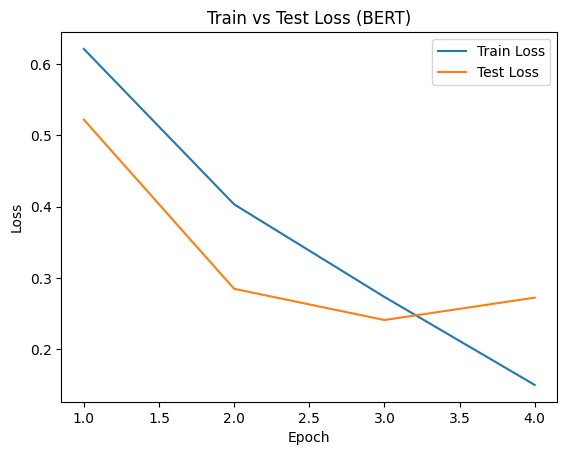

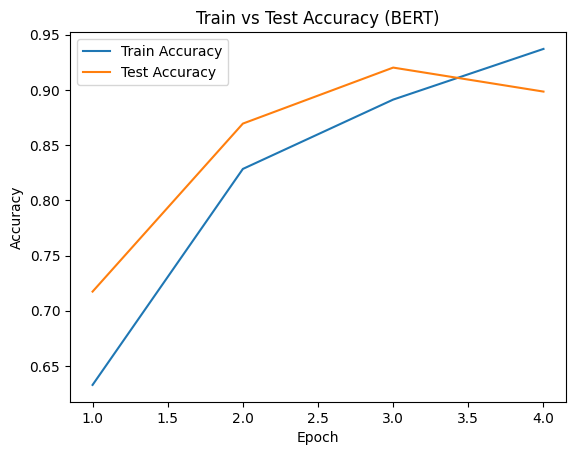

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import BertModel, DataCollatorWithPadding
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt


collator = DataCollatorWithPadding(tokenizer=tokenizer) #For faster training sequence padding per batch convert label -> labels

#train_loader = DataLoader(dataset["train"], batch_size=16, shuffle=True)
#test_loader = DataLoader(dataset["test"], batch_size=16)
train_loader = DataLoader(dataset["train"], batch_size=16, shuffle=True, collate_fn=collator)
test_loader = DataLoader(dataset["test"], batch_size=16, collate_fn=collator) #BERT is heavier than MLP, use smaller batch


# -----------------------------
# BERT MODEL
# -----------------------------
class SENA(nn.Module):
    def __init__(self):
        super(SENA, self).__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(self.bert.config.hidden_size, 2)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        # CLS token representation
        cls_output = outputs.last_hidden_state[:, 0, :]

        x = self.dropout(cls_output)
        x = self.fc(x)
        return x


model = SENA()

criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)  # lower LR for BERT
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5) #AdamW optimizer for transformer is standard


# -----------------------------
# STORE METRICS
# -----------------------------
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

epochs = range(1, 5)  # fewer epochs for BERT (important!)

# -----------------------------
# TRAINING LOOP
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in epochs:
    model.train()
    total_loss = 0
    all_train_preds, all_train_labels = [], []

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    train_loss = total_loss / len(train_loader)
    train_acc = accuracy_score(all_train_labels, all_train_preds)
    print(f"Epoch {epoch}, Total Loss: {total_loss:.4f}")

    # -----------------------------
    # TEST LOOP
    # -----------------------------
    total_loss = 0
    all_test_preds, all_test_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            input_ids = batch["input_ids"]
            attention_mask = batch["attention_mask"]
            labels = batch["labels"]

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_test_preds.extend(preds.cpu().numpy())
            all_test_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / len(test_loader)
    test_acc = accuracy_score(all_test_labels, all_test_preds)

    # store metrics
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f}, Test  Acc: {test_acc:.4f}")
    print("-" * 40)

# -----------------------------
# FINAL METRICS
# -----------------------------
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        outputs = model(input_ids, attention_mask)
        predictions = torch.argmax(outputs, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy_se = accuracy_score(all_labels, all_preds)
f1_se = f1_score(all_labels, all_preds)
precision_se = precision_score(all_labels, all_preds)
recall_se = recall_score(all_labels, all_preds)

print('\nFinal model performance on test set:')
print("Accuracy:", accuracy_se)
print("F1-score:", f1_se)
print("Precision:", precision_se)
print("Recall:", recall_se)

# -----------------------------
# PLOTS
# -----------------------------

# Loss plot
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss (BERT)")
plt.legend()
plt.show()

# Accuracy plot
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy (BERT)")
plt.legend()
plt.show()
    

# 8- Compare the final model performances

In [14]:
import pandas as pd

df_plot = pd.DataFrame({
    "Accuracy": [accuracy_mlp, accuracy_ls, accuracy_se],
    "F1": [f1_mlp, f1_ls, f1_se],
    "Precision": [precision_mlp, precision_ls, precision_se],
    "Recall": [recall_mlp, recall_ls, recall_se]
}, index=["MLP", "LSTM", "SENA"])
df_plot 

,Accuracy,F1,Precision,Recall
MLP,0.869565,0.869565,0.857143,0.882353
LSTM,0.847826,0.844444,0.850746,0.838235
SENA,0.898551,0.902778,0.855263,0.955882


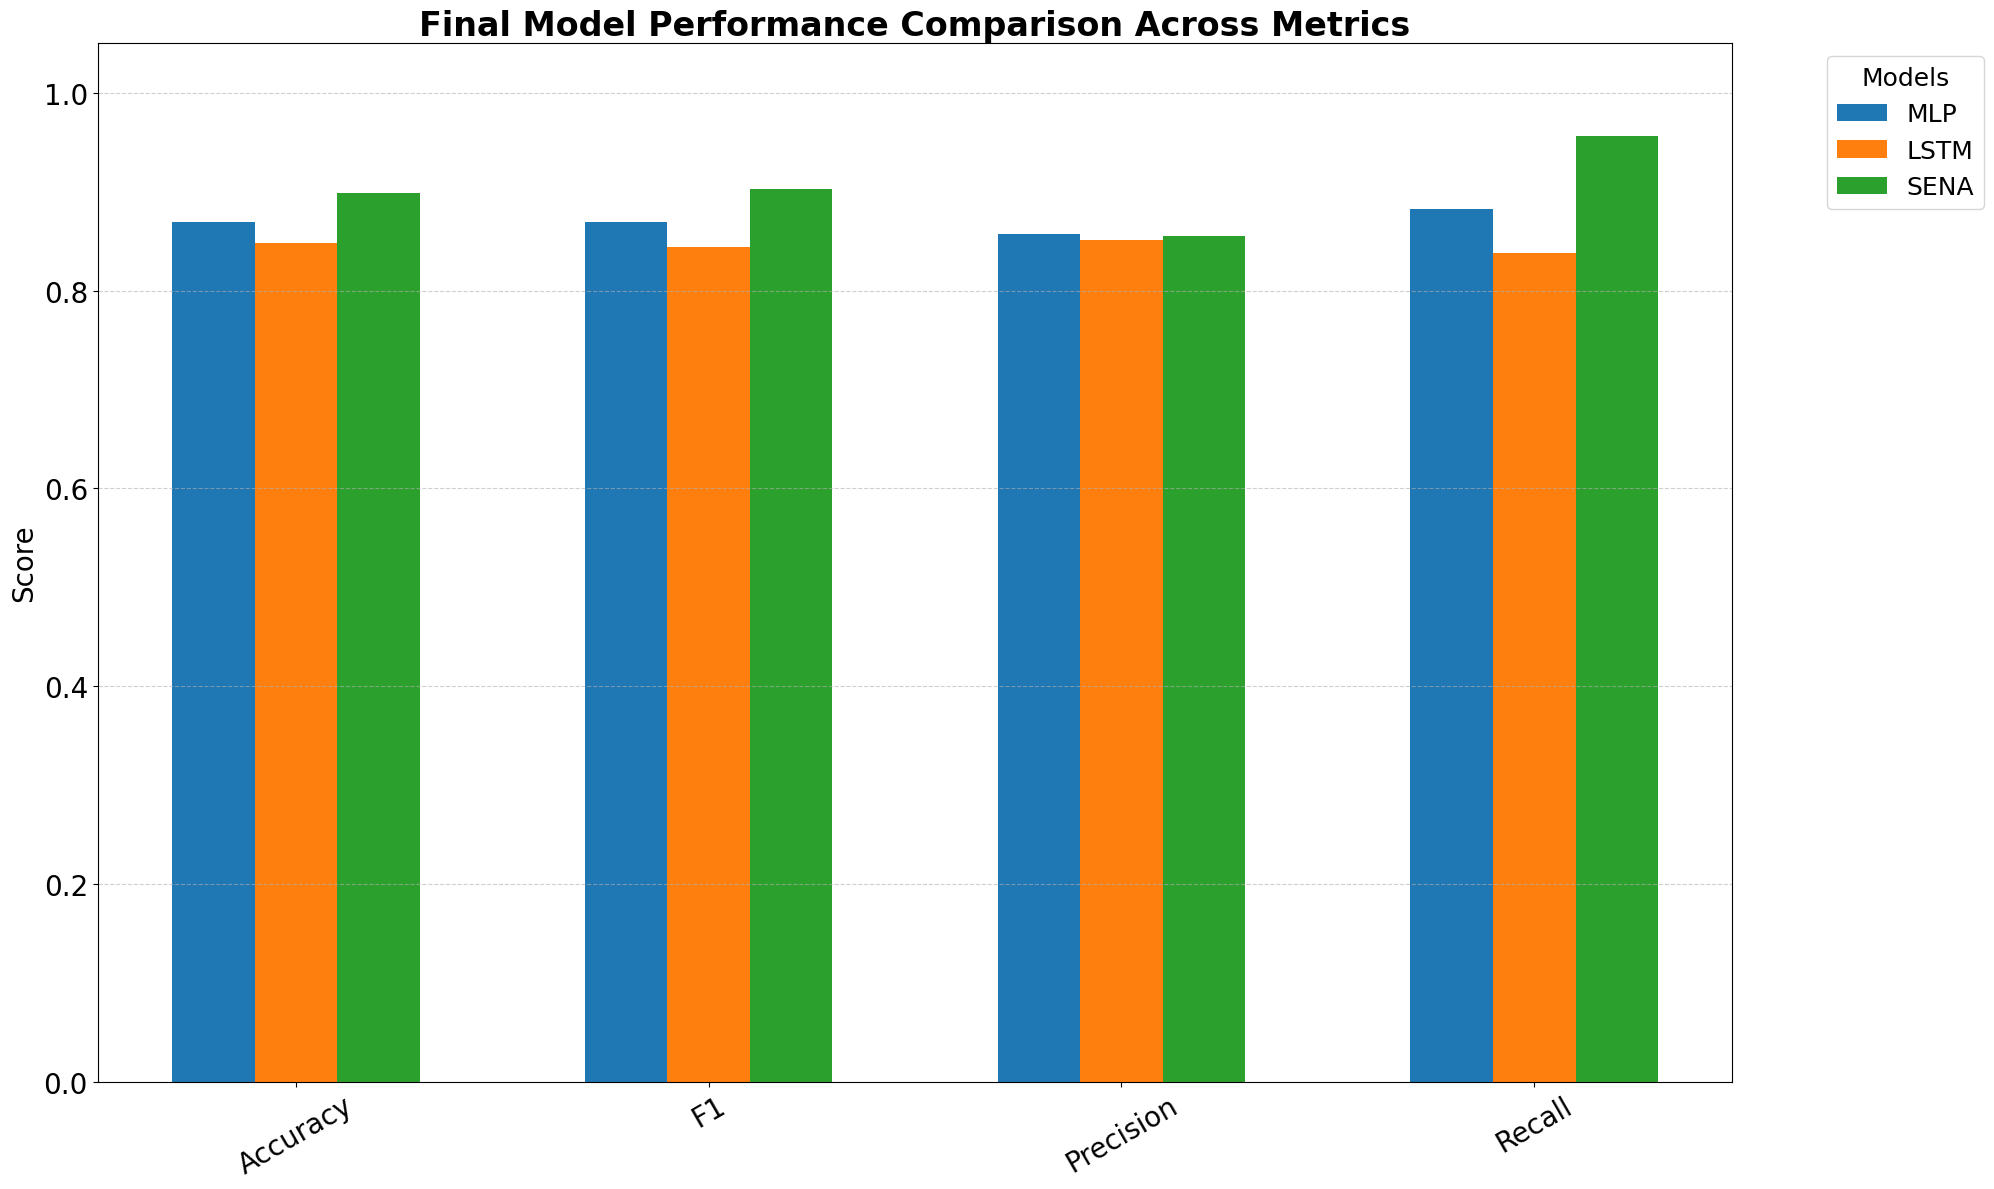

In [15]:
import numpy as np
import matplotlib.pyplot as plt

metrics = df_plot.columns

plt.figure(figsize=(20, 12))
bar_width = 0.2
x = np.arange(len(metrics))

for i, model in enumerate(df_plot.index):
    plt.bar(x + i * bar_width, df_plot.loc[model],
            width=bar_width, label=model)

# Formatting
plt.xticks(x + bar_width * (len(df_plot.index) / 2 - 0.5),
           metrics, rotation=30, fontsize=20)
plt.ylabel("Score", fontsize=20)
plt.title("Final Model Performance Comparison Across Metrics",
          fontsize=24, fontweight="bold")

plt.legend(title="Models", title_fontsize=18, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=18)
plt.ylim(0, 1.05)
plt.yticks(fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# 9- Compare the average accuracy performance of models 

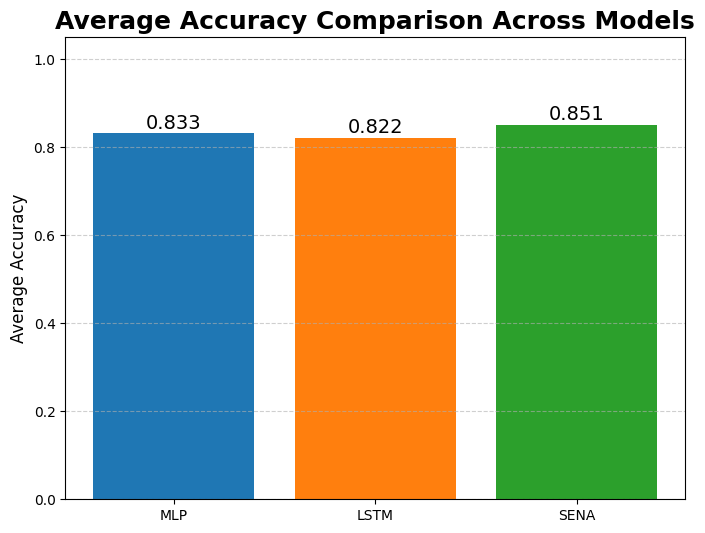

In [18]:
mlp_acc = np.array([0.7174,0.7826,0.8116,0.8551,0.8406,0.8478,0.8696,0.8623,0.8696,0.8696])
mlp_avg_acc = float(np.mean(mlp_acc))

ls_acc = np.array([0.7536,0.8261,0.8188,0.8188,0.8406,0.8551,0.8333,0.8043,0.8478])
ls_avg_acc = float(np.mean(ls_acc))

se_acc = np.array([0.7174,0.8696,0.9203,0.8986])
se_avg_acc = float(np.mean(se_acc))

models = ["MLP", "LSTM", "SENA"]
avg_acc = [mlp_avg_acc, ls_avg_acc, se_avg_acc]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# Plot
plt.figure(figsize=(8, 6))
plt.bar(models, avg_acc, color=colors)

# Add value labels on top
for i, v in enumerate(avg_acc):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=14)

plt.ylabel("Average Accuracy", fontsize=12)
plt.title("Average Accuracy Comparison Across Models", fontsize=18, fontweight="bold")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()
